## SpendWise AI - Notebook 05: Spending Forecaster

**Objective:** Predict future spending using Transformer-based time-series model

**Model:** Custom Transformer encoder (trained from scratch)

**What you'll learn:**
- Time-series data preparation (windowing)
- Positional encoding for sequences
- Transformer encoder architecture
- Sequence-to-value prediction

### 1. Imports & Setup

In [50]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Project root
PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "src").exists():
    pass
elif PROJECT_ROOT.name == "src" and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
elif (PROJECT_ROOT / "spendwise-ai" / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT / "spendwise-ai"
(PROJECT_ROOT / "models" / "forecaster_model").mkdir(parents=True, exist_ok=True)

Device: cpu


### 2. Prepare Time-Series Data

We create weekly total spending per user, then sequences: [Week1, Week2, Week3, Week4] predicts Week5; [Week2, Week3, Week4, Week5] predicts Week6.

In [51]:
transactions_df = pd.read_csv(PROJECT_ROOT / "data/synthetic/transactions_full.csv")
transactions_df["date"] = pd.to_datetime(transactions_df["date"])
print(f"Loaded {len(transactions_df):,} transactions")

Loaded 122,754 transactions


In [52]:
def create_weekly_totals(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate transactions to weekly total spending per user."""
    expenses = df[df["amount"] < 0].copy()
    expenses["amount"] = expenses["amount"].abs()
    expenses["week"] = expenses["date"].dt.to_period("W")
    weekly = expenses.groupby(["user_id", "week"])["amount"].sum().reset_index()
    weekly["week"] = weekly["week"].astype(str)
    return weekly

In [53]:
weekly_totals = create_weekly_totals(transactions_df)
print(f"Weekly totals created")
print(f"   Total records: {len(weekly_totals):,}")
print(f"   Users: {weekly_totals['user_id'].nunique()}")
print(f"   Weeks: {weekly_totals['week'].nunique()}")
print(f"\nSample data:")
print(weekly_totals.head(10))

Weekly totals created
   Total records: 2,600
   Users: 100
   Weeks: 26

Sample data:
     user_id                   week    amount
0  user_0000  2025-08-25/2025-08-31   5867.55
1  user_0000  2025-09-01/2025-09-07  11769.06
2  user_0000  2025-09-08/2025-09-14  10939.06
3  user_0000  2025-09-15/2025-09-21   8061.71
4  user_0000  2025-09-22/2025-09-28  11133.04
5  user_0000  2025-09-29/2025-10-05   8706.72
6  user_0000  2025-10-06/2025-10-12   7193.65
7  user_0000  2025-10-13/2025-10-19  11148.74
8  user_0000  2025-10-20/2025-10-26   4093.33
9  user_0000  2025-10-27/2025-11-02   5175.25


In [54]:
print(f"Weekly spending statistics:")
print(f"   Mean: ${weekly_totals['amount'].mean():.2f}")
print(f"   Std: ${weekly_totals['amount'].std():.2f}")
print(f"   Min: ${weekly_totals['amount'].min():.2f}")
print(f"   Max: ${weekly_totals['amount'].max():.2f}")

Weekly spending statistics:
   Mean: $5817.97
   Std: $3175.47
   Min: $428.64
   Max: $21275.87


### 3. Create Sequences for Training

Lookback: past weeks to use. Horizon: weeks ahead to predict (we use 1). Example: lookback=4 gives input [W1,W2,W3,W4] and target W5.

In [55]:
LOOKBACK = 8
HORIZON = 1

def create_sequences(df: pd.DataFrame, lookback: int, horizon: int) -> tuple:
    """Create input sequences and targets. Returns X (n_samples, lookback), y (n_samples,)."""
    sequences, targets = [], []
    for user_id in df["user_id"].unique():
        user_data = df[df["user_id"] == user_id].sort_values("week")
        amounts = user_data["amount"].values
        for i in range(len(amounts) - lookback - horizon + 1):
            sequences.append(amounts[i : i + lookback])
            targets.append(amounts[i + lookback + horizon - 1])
    return np.array(sequences, dtype=np.float32), np.array(targets, dtype=np.float32)

In [56]:
X, y = create_sequences(weekly_totals, LOOKBACK, HORIZON)
print(f"Sequences created")
print(f"   X shape: {X.shape} (samples, lookback)")
print(f"   y shape: {y.shape}")
print(f"\nExample: Input (8 weeks): {X[0].round(2)}, Target (week 9): {y[0]:.2f}")

Sequences created
   X shape: (1800, 8) (samples, lookback)
   y shape: (1800,)

Example: Input (8 weeks): [ 5867.55 11769.06 10939.06  8061.71 11133.04  8706.72  7193.65 11148.74], Target (week 9): 4093.33


### 4. Normalize Data & Split

In [57]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

In [58]:
n_samples = len(X_scaled)
train_size = int(0.7 * n_samples)
val_size = int(0.15 * n_samples)
indices = np.random.permutation(n_samples)
train_idx = indices[:train_size]
val_idx = indices[train_size : train_size + val_size]
test_idx = indices[train_size + val_size :]
X_train, y_train = X_scaled[train_idx], y_scaled[train_idx]
X_val, y_val = X_scaled[val_idx], y_scaled[val_idx]
X_test, y_test = X_scaled[test_idx], y_scaled[test_idx]
print(f"Data split: Train {len(X_train)}, Val {len(X_val)}, Test {len(X_test)}")

Data split: Train 1260, Val 270, Test 270


### 5. PyTorch Dataset

In [59]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx].unsqueeze(-1), self.y[idx]

In [60]:
BATCH_SIZE = 64
train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset = TimeSeriesDataset(X_val, y_val)
test_dataset = TimeSeriesDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
sample_x, sample_y = train_dataset[0]
print(f"Datasets created. Sample X shape: {sample_x.shape}, y shape: {sample_y.shape}")

Datasets created. Sample X shape: torch.Size([8, 1]), y shape: torch.Size([])


### 6. Positional Encoding

Transformers have no sense of order. Positional encoding adds position information (sine/cosine at different frequencies).

In [61]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 100, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model > 1:
            pe[:, 1::2] = torch.cos(position * div_term[: d_model // 2])
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1), :])

### 7. Build Transformer Forecaster

Input (batch, lookback, 1) to Linear embedding to d_model, positional encoding, Transformer encoder, global average pooling, prediction head to single value.

In [62]:
class SpendingForecaster(nn.Module):
    def __init__(self, input_dim: int = 1, d_model: int = 64, nhead: int = 4, num_layers: int = 2, dim_feedforward: int = 128, dropout: float = 0.1, max_len: int = 100):
        super().__init__()
        self.d_model = d_model
        self.input_embedding = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len, dropout)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Sequential(nn.Linear(d_model, d_model // 2), nn.ReLU(), nn.Dropout(dropout), nn.Linear(d_model // 2, 1))
    def forward(self, x):
        x = self.input_embedding(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x).mean(dim=1)
        return self.fc_out(x).squeeze(-1)

In [63]:
model = SpendingForecaster(input_dim=1, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1, max_len=LOOKBACK + 10)
model.to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Forecaster initialized: d_model 64, heads 4, layers 2, total parameters {total_params:,}")
test_input = torch.randn(2, LOOKBACK, 1).to(device)
print(f"Test input shape: {test_input.shape}, output shape: {model(test_input).shape}")

Forecaster initialized: d_model 64, heads 4, layers 2, total parameters 69,185
Test input shape: torch.Size([2, 8, 1]), output shape: torch.Size([2])


### 8. Training Configuration

In [64]:
LEARNING_RATE = 1e-3
NUM_EPOCHS = 50
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
criterion = nn.MSELoss()
print(f"Training: LR {LEARNING_RATE}, Epochs {NUM_EPOCHS}, Loss MSE")

Training: LR 0.001, Epochs 50, Loss MSE


### 9. Training Functions

In [65]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch_x, batch_y in dataloader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(batch_x), batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss, all_preds, all_targets = 0, [], []
    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            preds = model(batch_x)
            total_loss += criterion(preds, batch_y).item()
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
    return {"loss": total_loss / len(dataloader), "predictions": np.array(all_preds), "targets": np.array(all_targets)}

### 10. Train the Model

In [66]:
history = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")
best_model_state = None
print("Training Forecaster...")
print("=" * 50)
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_metrics = evaluate(model, val_loader, criterion, device)
    val_loss = val_metrics["loss"]
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    scheduler.step(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
print("=" * 50)
print(f"Training complete. Best val loss: {best_val_loss:.4f}")

Training Forecaster...
Epoch  10/50 | Train Loss: 0.7539 | Val Loss: 0.7631
Epoch  20/50 | Train Loss: 0.7285 | Val Loss: 0.7521
Epoch  30/50 | Train Loss: 0.7335 | Val Loss: 0.7510
Epoch  40/50 | Train Loss: 0.7248 | Val Loss: 0.7550
Epoch  50/50 | Train Loss: 0.7374 | Val Loss: 0.7549
Training complete. Best val loss: 0.7398


### 11. Visualize Training

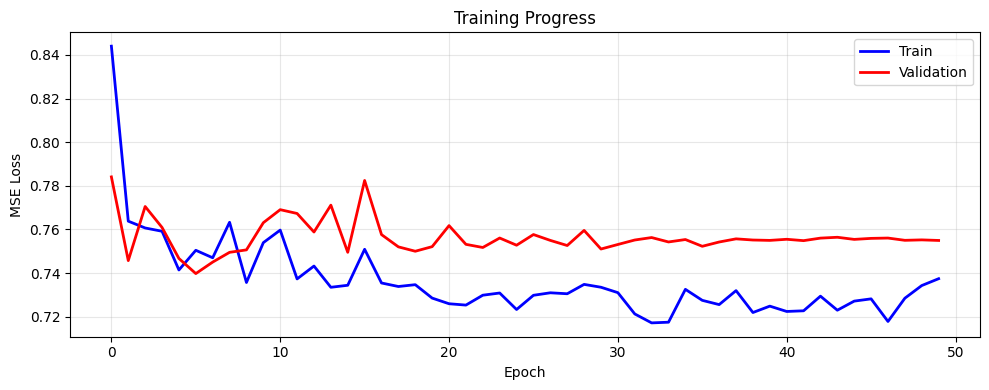

In [67]:
plt.figure(figsize=(10, 4))
plt.plot(history["train_loss"], "b-", label="Train", linewidth=2)
plt.plot(history["val_loss"], "r-", label="Validation", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Progress")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "models/forecaster_model/training_history.png", dpi=150, bbox_inches="tight")
plt.show()

### 12. Evaluate on Test Set

In [68]:
model.load_state_dict(best_model_state)
test_metrics = evaluate(model, test_loader, criterion, device)
preds_original = scaler_y.inverse_transform(test_metrics["predictions"].reshape(-1, 1)).flatten()
targets_original = scaler_y.inverse_transform(test_metrics["targets"].reshape(-1, 1)).flatten()
mae = mean_absolute_error(targets_original, preds_original)
rmse = np.sqrt(mean_squared_error(targets_original, preds_original))
mape = np.mean(np.abs((targets_original - preds_original) / (targets_original + 1e-8))) * 100
print(f"Test Results: MAE ${mae:.2f}, RMSE ${rmse:.2f}, MAPE {mape:.2f}%")

Test Results: MAE $1768.01, RMSE $2210.00, MAPE 43.94%


### 13. Visualize Predictions

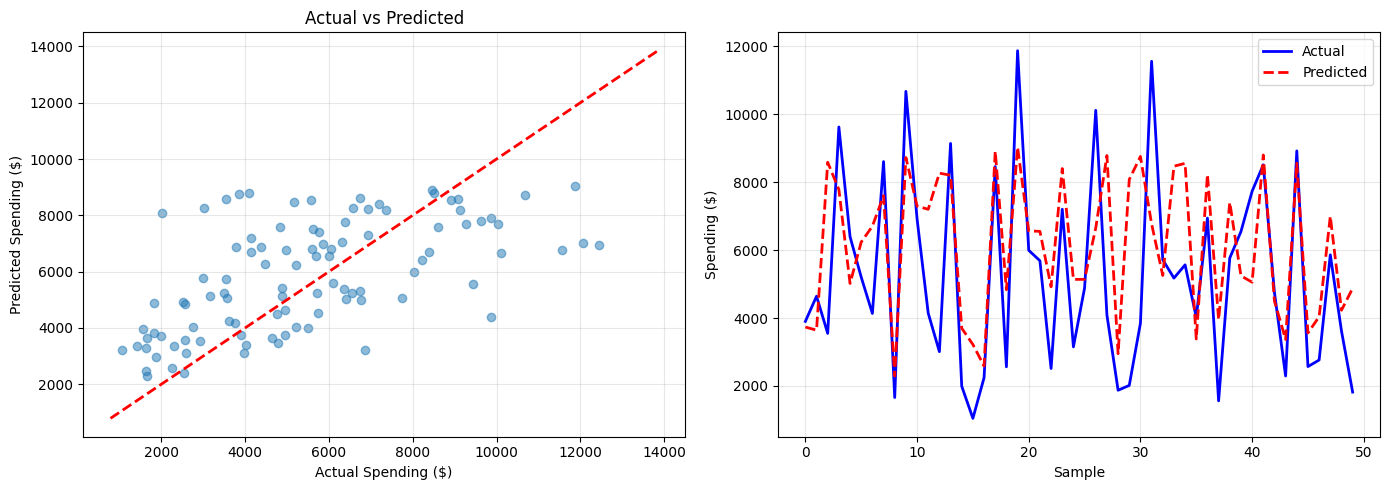

In [69]:
n_show = 100
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(targets_original[:n_show], preds_original[:n_show], alpha=0.5)
axes[0].plot([targets_original.min(), targets_original.max()], [targets_original.min(), targets_original.max()], "r--", linewidth=2)
axes[0].set_xlabel("Actual Spending ($)")
axes[0].set_ylabel("Predicted Spending ($)")
axes[0].set_title("Actual vs Predicted")
axes[0].grid(True, alpha=0.3)
axes[1].plot(targets_original[:50], "b-", label="Actual", linewidth=2)
axes[1].plot(preds_original[:50], "r--", label="Predicted", linewidth=2)
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("Spending ($)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "models/forecaster_model/predictions.png", dpi=150, bbox_inches="tight")
plt.show()

### 14. Build Forecaster Class for Production

In [70]:
class SpendingForecasterInference:
    def __init__(self, model_path: str = None):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if model_path:
            checkpoint = torch.load(f"{model_path}/model.pt", map_location=self.device)
            config = checkpoint["config"]
            self.model = SpendingForecaster(input_dim=config["input_dim"], d_model=config["d_model"], nhead=config["nhead"], num_layers=config["num_layers"])
            self.model.load_state_dict(checkpoint["model_state_dict"])
            self.scaler_mean, self.scaler_std = checkpoint["scaler_X_mean"], checkpoint["scaler_X_std"]
            self.scaler_y_mean, self.scaler_y_std = checkpoint["scaler_y_mean"], checkpoint["scaler_y_std"]
            self.lookback = config["lookback"]
        else:
            self.model = model
            self.scaler_mean, self.scaler_std = scaler_X.mean_[0], scaler_X.scale_[0]
            self.scaler_y_mean, self.scaler_y_std = scaler_y.mean_[0], scaler_y.scale_[0]
            self.lookback = LOOKBACK
        self.model.to(self.device)
        self.model.eval()
    def predict(self, spending_history: list) -> dict:
        if len(spending_history) < self.lookback:
            raise ValueError(f"Need at least {self.lookback} weeks of history")
        history = np.array(spending_history[-self.lookback :], dtype=np.float32)
        history_scaled = (history - self.scaler_mean) / self.scaler_std
        x = torch.FloatTensor(history_scaled).unsqueeze(0).unsqueeze(-1).to(self.device)
        with torch.no_grad():
            pred_scaled = self.model(x).item()
        prediction = pred_scaled * self.scaler_y_std + self.scaler_y_mean
        margin = prediction * 0.1
        return {"predicted_spending": round(prediction, 2), "lower_bound": round(prediction - margin, 2), "upper_bound": round(prediction + margin, 2)}

### 15. Test the Forecaster

In [71]:
print("Testing Forecaster\n")
forecaster = SpendingForecasterInference()
test_cases = [
    {"name": "Steady spender", "history": [1800, 1850, 1900, 1820, 1880, 1900, 1850, 1870]},
    {"name": "Increasing trend", "history": [1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200]},
    {"name": "Decreasing trend", "history": [2500, 2400, 2300, 2200, 2100, 2000, 1900, 1800]},
    {"name": "Variable spender", "history": [1500, 2500, 1800, 2200, 1600, 2400, 1700, 2100]},
]
print("=" * 60)
for case in test_cases:
    result = forecaster.predict(case["history"])
    avg = np.mean(case["history"])
    print(f"\n{case['name']}: History avg ${avg:.2f}, Predicted ${result['predicted_spending']:.2f}, Range ${result['lower_bound']:.2f}-${result['upper_bound']:.2f}")

Testing Forecaster


Steady spender: History avg $1858.75, Predicted $2604.31, Range $2343.88-$2864.74

Increasing trend: History avg $1850.00, Predicted $2605.79, Range $2345.21-$2866.37

Decreasing trend: History avg $2150.00, Predicted $2802.55, Range $2522.30-$3082.81

Variable spender: History avg $1975.00, Predicted $2669.67, Range $2402.70-$2936.63


### 16. Save Model

In [72]:
save_path = PROJECT_ROOT / "models" / "forecaster_model"
save_path.mkdir(parents=True, exist_ok=True)
torch.save({
    "model_state_dict": best_model_state,
    "config": {"input_dim": 1, "d_model": 64, "nhead": 4, "num_layers": 2, "lookback": LOOKBACK},
    "scaler_X_mean": scaler_X.mean_[0], "scaler_X_std": scaler_X.scale_[0],
    "scaler_y_mean": scaler_y.mean_[0], "scaler_y_std": scaler_y.scale_[0],
    "metrics": {"mae": mae, "rmse": rmse, "mape": mape},
}, save_path / "model.pt")
print(f"Model saved to {save_path}")

Model saved to /Users/patel/Documents/E/MPS Sem 5/EAI 6020/Final_Project/spendwise-ai/models/forecaster_model


### 17. Save Module for Production

In [73]:
import nbformat

notebook_path = PROJECT_ROOT / "src" / "05_spending_forecaster.ipynb"
nb = nbformat.read(str(notebook_path), as_version=4)

code_snippets = []
for cell in nb.cells:
    if cell.get("cell_type") == "code":
        src = cell.get("source", "")
        if isinstance(src, list):
            src = "".join(src)
        if (
            "class TimeSeriesDataset" in src
            or "class PositionalEncoding" in src
            or "class SpendingForecaster(" in src
            or "class SpendingForecasterInference" in src
        ):
            code_snippets.append(src)

module_code = """from dataclasses import dataclass
from typing import Tuple

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset
"""

module_code += "\n\n".join(code_snippets) + "\n"

module_path = PROJECT_ROOT / "src" / "spending_forecaster.py"
module_path.parent.mkdir(parents=True, exist_ok=True)
with open(module_path, "w") as f:
    f.write(module_code)
print(f"Module saved to {module_path}")

Module saved to /Users/patel/Documents/E/MPS Sem 5/EAI 6020/Final_Project/spendwise-ai/src/spending_forecaster.py


### Summary

- Time-series windowing and sequences; positional encoding; Transformer encoder for sequence-to-value prediction.
- Trained forecaster; MAE/RMSE/MAPE on test set; SpendingForecasterInference for production.
- Next: Notebook 06 (or LLM integration).

In [74]:
# Module saved by the cell under '17. Save Module for Production'


In [75]:
# Module saved by the cell under '17. Save Module for Production'
